## TRANSPORTE DE 2 ESPECIES EN EQUILIBRIO CON EL YESO  (1D) 
## Modelación de la concentración $c_1= SO_4^{2-}$
### Flujo y transporte conservativo en 1D utilizando GWF, GWT y Flopy

$$
\frac{\partial}{\partial x}( K \frac{\partial h }{\partial x})+ q_s = S_s \frac{\partial h }{\partial t} $$

$$
    \frac {\partial\left(\theta C^k\right)}{\partial t}  = \frac{\partial}{\partial x}\left(\theta D \frac{\partial C^k}{\partial x}\right)- \frac{\partial}{\partial x} (\theta v C^k) + q_s C^{k}_{s} $$

<!-- <img src="dominio1.png"> -->


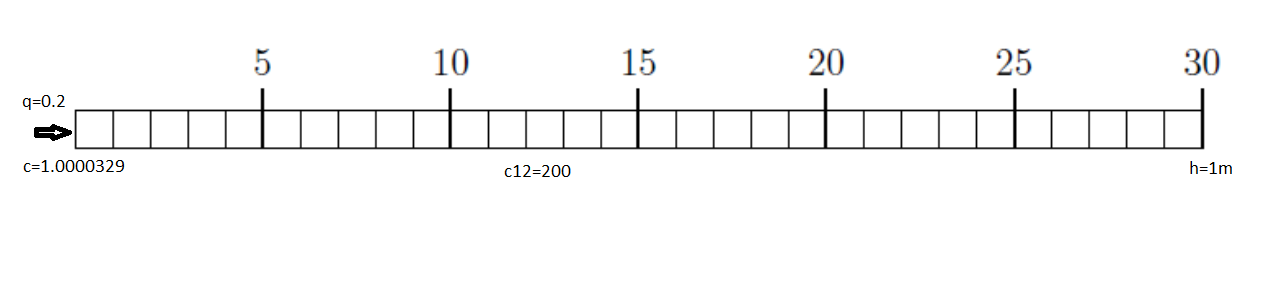

In [1]:
# insertar imagen incrustada en base64 dentro del notebook
from IPython.display import HTML
import base64
# Ruta de tu imagen
image_path = "dominio1.png"
# Leer imagen como base64
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")
# HTML para incrustar la imagen
html = f'<img src="data:image/png;base64,{image_base64}" />'
# Mostrar imagen
HTML(html)

* **Problema de flujo 1D**
* con las siguientes dimensiones del dominio: 
* LX=30m, LY=1m, LZ=1m
* considerando las siguientes condiciones de frontera:
* Flujo prescrito en la frontera izquierda CFI= 0.2 m3/d
* Carga prescrita en la frontera derecha CFD=1m  
* **Problema de transporte 1D**
* considerando las siguientes condiciones de frontera y condiciones iniciales:
* Concentración prescrita en el fluído entrante cfi =$c_1$= 1.0000329 en la frontera izquierda
* Concentración inicial $c_{1_i}$=1.0000329 en todo el dominio excepto en la celda 12, donde $c_{12i}$=200
* **Las propiedades físicas del problema son**:
* Conductividad hidráulica = 1.0 m/día
* Porosidad = 0.5
* Dispersividad longitudinal =0.2
* Factor de retardación =1.0
* Se simulan 40 días en 40 pasos de tiempo


## Se localiza dinámicamente el directorio "WMACC\src\ft1D" en la estructura de archivos del sistema y se añade al inicio de sys.path. Esto asegura que el intérprete de Python pueda importar módulos desde este directorio.

In [ ]:
import os, sys # interactuar con el sistema operativo para manejo de rutas y directorios, acceso a variables y funciones.
c_path = os.getcwd() #Obtener el directorio actual de trabajo como una cadena.
l_path = c_path.split(sep="\\") #Divide la ruta c_path en una lista, usando como separador  (\\)
i_wma = l_path.index('WMACC') #Busca y guarda el índice de la carpeta llamada 'WMACC' dentro de la lista l_path.
a_path = '\\'.join(l_path[:i_wma]) #a_path se construye uniendo elementos de l_path hasta el índice  'WMACC' inclusive
src_path = '\\WMACC\\src\\ft1D' #Cadena que define una ruta específica dentro del directorio 'WMACC' hacia un subdirectorio de código fuente
if not(src_path in sys.path[0]): #Si la ruta src_path no es el primer elemento en la lista sys.path (que Python usa para buscar módulos), se inserta esta ruta al inicio de la lista
    sys.path.insert(0, os.path.abspath(a_path + src_path)) 
print(c_path)
print(l_path)
print(i_wma)
print('a_path = ',a_path)
print('src_path = ',src_path)


## Importa librerías para cálculos numéricos (numpy), visualización (matplotlib), interacción con modelos MODFLOW (flopy), y módulos personalizados (xmf6)

In [ ]:
import os, sys #Importar módulos de sistema para interactuar con el sistema operativo y manipular el entorno de Python.
import numpy as np # Importar numpy como np: para cálculos numéricos y manejo de arrays.
import matplotlib.pyplot as plt #Función para crear visualizaciones gráficas de los datos.  plt.plot(), plt.show()

import flopy #Para la modelación de flujo subterráneo con MODFLOW y otras herramientas relacionadas.
from flopy.plot.styles import styles #Para aplicar estilos predefinidos a las gráficas de los modelos.
import xmf6 #Módulo específico para funciones extendidas en modelación.
from flow_1D import build_gwf_1D #Se importa build_gwf_1D de flow_1D para construir modelos de flujo subterráneo unidimensional.
from wexler1 import sol_analytical_t # Funciones para cálculo de la solución analítica
from sorption_decay import * # Definición de parámetros de decaimiento y sorción

## Paso 0. Descripción espacial del dominio

* El modelo de malla consiste de 1 capa, 31 columnas y 1 renglón.
* La longitud del renglón es de 30 [m]. (-0.5 a 29.5) [m]
* La longitud de la columna es 1 [m].
* Con la información anterior se calcula el ancho del renglón, DELC, y de las columnas, DELR, que en ambos casos debe ser 1 [m].
* La parte superior (TOP) de la celda es 1 [m] y la parte inferior (BOTTOM) es 0 [m].
* El espesor de la capa es igual a 1 [m], valor que se calcula de |TOP - BOTTOM|.

**<font color='Green'> [1] Konikow, L. F., Goode, D. J., & Hornberger, G. (1996, January 1). A three-dimensional method-of-characteristics solute-transport model (MOC3D). Water-Resources Investigations Report 96-4267.</font>** https://doi.org/10.3133/wri964267

**<font color='Green'> [2] Eliezer J. Wexler, (1992).
Analytical solutions for one-, two-, and three-dimensional solute transport in ground-water systems with uniform flow. U.S. Geological Survey Techniques of Water-Resources Investigations, Book 3, Chapter B7, 190 p.</font>** https://doi.org/10.3133/twri03b7

## Paso 1. Definición de parámetros del problema.

### Parámetros para la discretización del espacio.

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Length of system (rows) |30| m | `mesh.row_length` |
|Number of layers |1| | `mesh.nlay` |
|Number of rows |1| | `mesh.nrow` |
|Number of columns |31| | `mesh.ncol` |
|Column width |1| m | `mesh.delr` |
|Row width |1| m | `mesh.delc`|
|Top of the model |1| m | `mesh.top`|
|Layer bottom elevation  |0| m | `mesh.bottom` |

### 1a). Creación del objeto **mesh** utilizando el módulo xmf6
1. Se define **mesh** una discretización espacial usando **xmf6.MeshDis**
2. Se indican las características de (**mesh**).

In [ ]:
# discretización espacial usando xmf6.MeshDis
mesh = xmf6.MeshDis(
    nrow = 1,    # Number of rows
    ncol = 31,  # Number of columns
    nlay = 1,    # Number of layers
    row_length = 31.0,    # Length of system ($m$)
    column_length = 1.0,  # Length of system ($m$)
    top = 1.0,   # Top of the model ($m$)
    bottom = 0.0,  # Layer bottom elevation ($m$)
)
#Visualización de los Parámetros de (mesh) con la etiqueta 'Space discretization'
xmf6.nice_print(mesh.get_dict(), 'Space discretization')

### 1b). Parámetros para la discretización del tiempo.

* La simulación consta de un período de estrés que tiene una duración de 40 days.
* El período de estrés se divide en 40 pasos de tiempo del mismo tamaño.
  
|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Number of stress periods |1| | `tm_par['nper']` |
|Total time |40| days | `tm_par['total_time']` |
|Number of time steps| 40 | | `tm_par['nstp']`|
|Multiplier | 1 | | `tm_par['tsmult']`|

### 1b).Creación de **tm_par**


In [ ]:
# Discretización temporal
tm_par = dict( 
    nper = 1,  # Number of periods
    total_time = 40.0,  # Simulation time ($d$)
    nstp = 40,   # Number of time steps
    tsmult = 1.0  # Multiplier for the length of successive time steps.
)
# Visualización de los Parámetros de Tiempo con una etiqueta descriptiva
xmf6.nice_print(tm_par, 'Time discretization')
print("nper = ",tm_par['nper']) # Esto es extra


### 1c). Definición de parámetros físicos.

  
|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Specific discharge |0.2| m/d  | `ph_par['specific_discharge']` |
|Hydraulic conductivity |1.0| m/d | `ph_par['hydraulic_conductivity']` |
|Source concentration |1.0000329| unitless | `ph_par['source_concentration']` |
|Porosity | 0.5 | unitless |  `ph_par['porosity']` |
|Initial Concentration | ($c_{1_i}$=1.0000329, $c_{1_{12_i}}$=200) | unitless | `ph_par['initial_concentration']` |
|Longitudinal Dispersivity | 0.2 |  | `ph_par['longitudinal_dispersivity']` |
|Retardation Factor | 1.0 | unitless | `ph_par['retardation_factor']` |
|Decay Rate | 0.0 |  | `ph_par['decay_rate']` |
|Dispersion coefficient | | | `ph_par["dispersion_coefficient"]` |

$$
\text{Dispersion Coefficient} = \dfrac{\text{Longitudinal Dispersivity} \times \text{Specific Discharge}}{\text{Retardation Factor}}
$$

### 1c). Definiendo unidades **ml_units** y parámetros físicos **ph_par** del sistema


In [1]:
# Definimos arreglo temp=np.zeros(nlay,nrow,ncol),dtype=float) para establecer initial_concentration como arreglo
nrow = 1    # Number of rows
ncol = 31  # Number of columns
nlay = 1    # Number of layers

init_conc = np.ones((nlay,nrow,ncol),dtype=float) # init_conc=diccionario de conc.init,
init_conc = init_conc*1.0000329
init_conc[:,0,11]=200.0
#print(temp)

# Definición de unidades a utilizar
ml_units = {
    "time": "days",
    "length": "meters"
}
xmf6.nice_print(ml_units, 'Units')

# Definición de parámetros físicos a utilizar en el modelo
ph_par = dict(
    specific_discharge = 0.2,  # Specific discharge ($m/d$)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($m/d$)
    source_concentration = 1.0000329,  # Source concentration (unitless)
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    initial_concentration = init_conc,  # Initial concentration (unitless)
    longitudinal_dispersivity = 0.2,
    retardation_factor = 1.0,
    decay_rate =  0.0
)
ph_par["dispersion_coefficient"] = ph_par["longitudinal_dispersivity"] * ph_par["specific_discharge"] / ph_par["retardation_factor"]

print(f"Hydraulic conductivity: {ph_par['hydraulic_conductivity']} m/d")
print(f"Initial concentration: {ph_par['initial_concentration']} (unitless)")
#print(f"Dispersion coefficient: {ph_par['dispersion_coefficient']}")
#xmf6.nice_print(ph_par, 'Physical parameters')


NameError: name 'np' is not defined

## Paso 2. Configuración de rutas de trabajo, nombres de archivos para una simulación de MODFLOW 6 de flujo y transporte, organizando los parámetros de entrada y salida en **diccionarios** para facilitar su manejo.

In [ ]:
#2a).  ----- Definición de Parámetros -----
os_par = dict( #Diccionario que almacena 4 elementos del entorno de simulación.
    ws = os.getcwd() + '/output', # Ruta del directorio de trabajo donde se guardarán los archivos de salida.
    mf6_exe = 'mf6.exe', # Nombre del ejecutable de MODFLOW 6, 'mf6.exe', que se utilizará para correr la simulación.
    flow_name = 'flow', # Nombre 'flow' para la simulación de flujo subterráneo.
    tran_name = 'transport' # Nombre que se le asignará a la simulación de transporte.
)
xmf6.nice_print(os_par, 'MODFLOW 6 environment')

#2a). El diccionario oc_par para definir los nombres de los archivos de salida
oc_par = dict( #Diccionario que contiene los nombres de archivos de salida generados durante la simulación
    head_file = f"{os_par['flow_name']}.hds", #Nombre del archivo de salida que almacenará las cargas hidráulicas con la extensión .hds
    fbudget_file = f"{os_par['flow_name']}.bud", #Nombre del archivo de salida que almacenará los valores del (flujo de agua) en la simulación de flujo.
    concentration_file=f"{os_par['tran_name']}.ucn", #Nombre del archivo que almacenará las concentraciones de la simulación de transporte.
    tbudget_file = f"{os_par['tran_name']}.bud", #Nombre del archivo que almacenará el balance de transporte (flujo de solutos) de la simulación de transporte.
)
#print(os_par)
#print("ws =", os_par['ws'])
xmf6.nice_print(oc_par, 'Output files') #imprime de forma clara y estilizada los nombres de los archivos de salida configurados en oc_par.

## Paso 3. (Modelo GWF) 
## 3a) Se construye, ejecuta y visualiza una simulación de flujo subterráneo 1D con MODFLOW en forma automatizada y sin mostrar detalles de ejecución.


In [ ]:
#3a). Resultados del flujo
sim_f, gwf = build_gwf_1D(mesh, tm_par, ph_par, ml_units, os_par, oc_par)
sim_f.write_simulation(silent=True) #Escribe los archivos de entrada necesarios para ejecutar la simulación.
sim_f.run_simulation(silent=True) #Ejecuta la simulación, sin mensajes en la consola durante la ejecución.
xmf6.plot_flow_1D(gwf, mesh, os_par, oc_par) #llama a la función **plot_flow_1D** para visualizar los resultados de la simulación de flujo

## Impresión de propiedades del objeto de simulación sim_f y del modelo de flujo gwf

In [ ]:
# Imprimir propiedades del objeto de simulación sim_f
print("Propiedades de sim_f: (Objeto de la simulación)")
print("Nombre de la simulación:", sim_f.name)
print("Directorio de trabajo:", sim_f.simulation_data.mfpath.get_sim_path())

# Imprimir propiedades del modelo de flujo gwf
print("Propiedades de gwf: (Objeto del modelo de flujo)")
print("Nombre del modelo:", gwf.name)
print("Número de paquetes:", len(gwf.package_dict))
print("Paquetes activos:", gwf.package_dict.keys())

## 3b). Extracción de datos de salida de MODFLOW: lectura de cargas hidráulicas del archivo .hds, balance de flujo del .bud, y calcula velocidades de flujo, procesando resultados de la simulación.

In [ ]:
# Obtenemos los resultados de la carga hidráulica
# Lectura de los resultados de la carga hidráulica (niveles de agua) desde el archivo de salida generado por la simulación.
head = flopy.utils.HeadFile( #Construye la ruta completa al archivo de cargas hidráulicas.
    os.path.join(os_par['ws'], #Es la ruta del directorio de salida.
                 oc_par['head_file'])).get_data() #es el nombre del archivo de cargas hidráulicas (por ejemplo, flow.hds).
# Obtenemos los resultados del BUDGET
# Lee los resultados del balance de flujo (flujo de agua) desde el archivo de salida generado por la simulación.
bud  = flopy.utils.CellBudgetFile( 
    os.path.join(os_par['ws'], #Construye la ruta completa al archivo de balance de flujo.
                 oc_par['fbudget_file']), #es el nombre del archivo de balance de flujo (por ejemplo, flow.bud).
    precision='double'
)
# Obtenemos las velocidades
# Extrae y calcula las velocidades (flujos específicos) a partir de los datos del balance de flujo.
spdis = bud.get_data(text='DATA-SPDIS')[0] #Extrae los datos de flujo específico (SPDIS) del archivo de balance de flujo.
# text='DATA-SPDIS': Filtra los datos para obtener solo los flujos específicos.
# **flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)**: Calcula las componentes del flujo específico (qx, qy, qz) 
# a partir de los datos de flujo y el modelo de flujo de agua subterránea (gwf).
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)

## 3c) Impresión de la carga hidráulica y la descarga específica en GWF

In [ ]:
# Imprimimos carga hidráulica y la descarga específica
print(head.shape, '\n', head)
print(qx.shape, '\n', qx)

#========================================================
# INICIA MODELO DE TRANSPORTE
#========================================================

## Paso 4. Simulation object
## Utilizando la biblioteca FloPy, se crea y configura un objeto MFSimulation (sim_t) para realizar la simulación de transporte de solutos en MODFLOW 6, estableciendo el nombre, el directorio de trabajo y su ejecutable.


In [ ]:
sim_t = flopy.mf6.MFSimulation(
    sim_name=os_par["tran_name"], 
    sim_ws=os_par["ws"], 
    exe_name=os_par["mf6_exe"]
)
print(sim_t)

## Paso 5. Time discretization object
## Discretización temporal utilizando FloPy. Se define el número de periodos de tiempo, la duración de cada periodo, el número de pasos de tiempo y el factor multiplicador del tamaño del paso.


In [ ]:
flopy.mf6.ModflowTdis(
    sim_t, #Objeto de simulación (MFSimulation) al que se le asocia esta configuración de discretización temporal.
    nper=tm_par["nper"], #Si tm_par["nper"] = 3, entonces la simulación tiene 3 periodos de tiempo.
    perioddata=((tm_par["total_time"], #Duración total del periodo.
                 tm_par["nstp"],       #Número de pasos de tiempo en el periodo.
                 tm_par["tsmult"]),),  #Factor de multiplicación del tamaño del paso de tiempo
    time_units=ml_units["time"]
)


## Paso 6. IMS object (solution calculation)
## Se configura el Solver (IMS) para MODFLOW 6 utilizando FloPy, especificando el método "bicgstab" para la aceleración lineal en la resolución de ecuaciones


In [ ]:
ims = flopy.mf6.ModflowIms(
    sim_t, 
    linear_acceleration="bicgstab"
)
print(ims)

## Paso 7. GWT model object (transport)
## Se crea y configura un modelo de transporte de agua subterránea (GWT) en MODFLOW 6 usando FloPy, habilitando el guardado de flujos.

* <font color='Green'> Langevin, C.D., Provost, A.M., Panday, Sorab, and Hughes, J.D., 2022, Documentation for the MODFLOW 6 Groundwater Transport Model: U.S. Geological Survey Techniques and Methods, book 6, chap. A61, 56 p., https://doi.org/10.3133/tm6A61.  

In [ ]:
gwt = flopy.mf6.ModflowGwt(
    sim_t, 
    modelname=os_par["tran_name"], 
    save_flows=True
)
print(gwt)

## Paso 8. Space discretization object
## Se configura la discretización espacial del modelo de transporte (GWT) en MODFLOW 6 usando FloPy. Define las unidades de longitud, las dimensiones de la malla (número de capas, filas y columnas), el tamaño de las celdas y las elevaciones superior e inferior del modelo

In [ ]:
dis = flopy.mf6.ModflowGwtdis(
    gwt,
    length_units=ml_units["length"],
    nlay=mesh.nlay,
    nrow=mesh.nrow,
    ncol=mesh.ncol,
    delr=mesh.delr,
    delc=mesh.delc,
    top=mesh.top,
    botm=mesh.bottom,
)
print("length_units =", ml_units["length"])
print("nlay =", mesh.nlay)
print("nrow =", mesh.nrow)
print("ncol =", mesh.ncol)
print("delr =", mesh.delr)
print("delc =", mesh.delc)
print("top =", mesh.top)
print("botm =", mesh.bottom)
print(dis)

## Paso 9. Initial conditions object
## Initial Conditions (IC) Package
## Se configuran las condiciones iniciales de concentración del modelo de transporte en MODFLOW 6. Establece una concentración inicial de 200.0 en una celda específica, y luego se asigna este array como las condiciones iniciales al modelo GWT usando FloPy

In [ ]:
# Definimos arreglo temp=np.zeros(nlay,nrow,ncol),dtype=float) para establecer initial_concentration 
nrow = 1    # Number of rows
ncol = 31  # Number of columns
nlay = 1    # Number of layers

init_cond = np.ones((nlay,nrow,ncol),dtype=float) 
init_cond = init_cond*1.0000329
init_cond[:,0,11]=200.0

ic = flopy.mf6.ModflowGwtic(
    gwt, #Objeto del modelo de transporte (ModflowGwt) al que se asociará este paquete.
    strt=init_cond
)
print(ic)

## Paso 10. Mobile Storage and Transfer (MST) Package
## Se configuran las propiedades del medio poroso y los procesos de transporte para un modelo GWT en MODFLOW 6 usando FloPy
 

In [ ]:
mst = flopy.mf6.ModflowGwtmst(
    gwt, #modelo de transporte de MODFLOW 6 en el que se aplica este paquete.
    porosity=ph_par["porosity"], #Especifica la porosidad del medio poroso, obtenida del diccionario de parámetros físicos ph_par.
    **get_sorption_dict(ph_par["retardation_factor"]), #devuelve un diccionario con los parámetros necesarios para modelar adsorción y desorción 
    **get_decay_dict(ph_par["decay_rate"], #especifica la tasa de decaimiento del contaminante.
                     ph_par["retardation_factor"] > 1.0), #condición booleana, indica si el decaimiento ocurre en la fase acuosa (False) o en la fase adsorbida (True).
)

print(mst)

## Paso 11. Advection (ADV) Package
## Se configura el esquema de advección para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy


In [ ]:
adv = flopy.mf6.ModflowGwtadv(
    gwt, 
    scheme="TVD"
)
print(adv)

## Paso 12. Dispersion (DSP) Package
## Se Configura la dispersión para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy.

In [ ]:
dsp = flopy.mf6.ModflowGwtdsp(
    gwt,
    xt3d_off=True,
    alh=ph_par["longitudinal_dispersivity"],
    ath1=ph_par["longitudinal_dispersivity"],
)

print(dsp)

## Paso 13. Se establece la conexión entre los resultados del modelo de flujo (GWF) y el modelo de transporte (GWT) en MODFLOW 6. Asocia archivos de salida de carga hidráulica y balance de flujo del GWF con el GWT, permitiendo que el modelo de transporte utilice la información del flujo de agua subterránea para simular el transporte de solutos.


In [ ]:
pd = [ 
    ("GWFHEAD", oc_par["head_file"], None),
    ("GWFBUDGET", oc_par["fbudget_file"], None),
]
    
fmi = flopy.mf6.ModflowGwtfmi(
    gwt, 
    packagedata=pd
)
print(fmi)

## Paso 14. Configura las fuentes de soluto para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy. Especifica que la fuente "WEL-1" (pozo) tiene una columna auxiliar "CONCENTRATION" que define la concentración del soluto inyectado.


In [ ]:
sourcerecarray = [["WEL-1", "AUX", "CONCENTRATION"]]
ssm = flopy.mf6.ModflowGwtssm(
    gwt, 
    sources=sourcerecarray
)
print(ssm)

## Paso 15. Observation locations
## Se define un diccionario obs_data que especifica puntos de observación para la simulación de transporte. Asocia un archivo CSV ("transporte.obs.csv") con una lista de puntos de observación,


In [ ]:
obs_data = {
    "transporte.obs.csv": [
        ("X005", "CONCENTRATION", (0, 0, 0)),
        ("X011", "CONCENTRATION", (0, 0, 11)),
        ("X030", "CONCENTRATION", (0, 0, 30)),
    ],
}

obs_package = flopy.mf6.ModflowUtlobs(
    gwt, 
    digits=10, 
    print_input=True, 
    continuous=obs_data
)

print(obs_package)

## Paso 16. Output object
## Se configuran las opciones de salida (OC) para el modelo de transporte (GWT) en MODFLOW 6 usando FloPy.

In [ ]:
oc = flopy.mf6.ModflowGwtoc(
    gwt,
    budget_filerecord=oc_par["tbudget_file"],
    concentration_filerecord=oc_par["concentration_file"],
    saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "LAST")],
    printrecord=[("CONCENTRATION", "LAST"), ("BUDGET", "LAST")],
)

print(oc)

## Paso 17. Write Input files.
##  Se le indica a FloPy para que escriba todos los archivos de entrada necesarios para ejecutar la simulación de transporte de solutos en MODFLOW 6.


In [ ]:
sim_t.write_simulation()

## Paso 18. Run simulation
## Se ejecuta la simulación de transporte de solutos previamente configurada en MODFLOW 6 utilizando Flopy. 


In [ ]:
sim_t.run_simulation()

## Paso 19. Postprocessing
##  Devuelve una lista con los nombres de los modelos que componen la simulación.
### Resultados del transporte

In [ ]:
# listar los nombres de los modelos incluidos en una simulación de MODFLOW 6.
sim_t.model_names

### mf6gwt_ra: Se extraen los datos específicos de una simulación de transporte de solutos realizada con MODFLOW 6 y se almacenan en esta variable
### ucnobj_mf6: Se extraen los resultados de concentración de solutos y se almacenan en esta variable

In [ ]:
mf6gwt_ra = sim_t.get_model("transport").obs.output.obs().data
ucnobj_mf6 = sim_t.transport.output.concentration()

In [ ]:
print(type(mf6gwt_ra), type(ucnobj_mf6))

In [ ]:
#print(mf6gwt_ra.shape)
#print(mf6gwt_ra) #(tiempo, C0, C40 y C110)

## Se extraen los tiempos de simulación para los datos de observación mf6gwt_ra

In [ ]:
simtimes = mf6gwt_ra["totim"]
simtimes.shape
print(type(simtimes), simtimes)


In [ ]:
obsnames = ["X005", "X011", "X030"]

## Visualización de cargas utilizando "flow.hds"

In [ ]:
from flopy.utils import HeadFile
from flopy.utils import UcnFile
import matplotlib.pyplot as plt
import numpy as np  # Importación necesaria para cálculos numéricos

def plot_head_lines(file_path, stress_period_index=-1):
    # Cargar archivo de cargas
    head_file = HeadFile(file_path)
    
    # Obtener todos los tiempos disponibles
    times = head_file.get_times()
    
    # Mostrar los períodos de estrés disponibles en una sola línea
    stress_periods_str = ", ".join([f"{i}: {t:.2f}" for i, t in enumerate(times)])
    print(f"\nTiempos disponibles: {stress_periods_str}")
    
    # Asegurar que el índice está dentro de los límites
    if stress_period_index < 0:
        stress_period_index = len(times) + stress_period_index  # Permite usar -1 para el último, -2 para el penúltimo, etc.
    
    if stress_period_index >= len(times):
        raise ValueError(f"El índice de período de estrés {stress_period_index} está fuera de rango. Hay {len(times)} disponibles.")
    
    # Obtener los datos de carga para el período seleccionado
    head_data = head_file.get_data(totim=times[stress_period_index])
    
    num_layers = head_data.shape[0]
    num_cols = head_data.shape[2]
    x = np.arange(num_cols)  # Eje X representando las columnas
    
    # Configuración de la figura
    fig, ax = plt.subplots(figsize=(10, 3))
    
    for i in range(num_layers):
        layer_data = np.nanmean(head_data[i], axis=0)  # Promedio por columna
        ax.plot(x, layer_data, label=f"Capa {i}")
    
    # Configuración de la gráfica
    ax.set_xlabel("Distancia [m]")
    ax.set_ylabel("Carga (m)")
    ax.set_title(f"Cargas por Capa   (Tiempo: {times[stress_period_index]:.2f})")
    ax.legend()
    ax.grid()
    
    plt.show()

# Uso del script para visualizar todas las capas de carga con líneas para un período de estrés específico
plot_head_lines("./output/flow.hds", stress_period_index=39)  # Cambia el índice según el periodo deseado


## Se visualiza el campo de concentraciones para t=t1, y t=t2, utilizando ucnobj_mf6

In [ ]:
# Visualización de la concentración en dos tiempos diferentes: (t1,t2)
import matplotlib.pyplot as plt

# Define los dos tiempos de interés
t1 = 10.0
t2 = 20.0
t3 = 30.0
t4 = 40.0

print('Tiempos disponibles:')
print(ucnobj_mf6.get_times())

# Obtén los datos de concentración simulados para cada tiempo
simconc_t1 = ucnobj_mf6.get_data(totim=t1).flatten()
simconc_t2 = ucnobj_mf6.get_data(totim=t2).flatten()
simconc_t3 = ucnobj_mf6.get_data(totim=t3).flatten()
simconc_t4 = ucnobj_mf6.get_data(totim=t4).flatten()

# Obtén las coordenadas (por ejemplo, x)
x, _, _ = mesh.get_coords()

print('Campo de concentraciones para t = ',t1,'dias')
print(simconc_t1) #Impresión numérica de datos de concentración
print('Campo de concentraciones para t = ',t2,'dias')
print(simconc_t2) #Impresión numérica de datos de concentración
print('Campo de concentraciones para t = ',t3,'dias')
print(simconc_t3) #Impresión numérica de datos de concentración
print('Campo de concentraciones para t = ',t4,'dias')
print(simconc_t4) #Impresión numérica de datos de concentración
# Crear la gráfica en formato de líneas para ambos tiempos
plt.figure(figsize=(10, 4))
plt.plot(x, simconc_t1, marker="o", linestyle="-", color="blue", label=f"Concentration at t = {t1} days")
plt.plot(x, simconc_t2, marker="s", linestyle="-", color="red",  label=f"Concentration at t = {t2} days")
plt.plot(x, simconc_t3, marker="s", linestyle="-", color="green",  label=f"Concentration at t = {t3} days")
plt.plot(x, simconc_t4, marker="s", linestyle="-", color="violet",  label=f"Concentration at t = {t4} days")
plt.xlabel("Distance (m)")
plt.ylabel("Normalized Concentration (unitless)")
plt.title("Comparison of Concentrations at Different Times")
plt.xlim(0, 30)

# Ajusta el límite superior del eje Y basado en el valor máximo de ambos conjuntos de datos
max_y = max(simconc_t1.max(), simconc_t2.max(), simconc_t3.max(), simconc_t4.max())
plt.ylim(0, max_y * 1.1)

plt.legend()
plt.show()